[Index](Index.ipynb) - [Prev](Hadamard_gate.ipynb) - [Next](SWAP_gate.ipynb)

### CNOT <a id='cnot'></a>
The CNOT (or controlled X) is a two qubit control gate and is highly use to create entangled states.
It flips the second qubit (the target qubit) if and only if the first qubit (the control qubit) is $|1\rangle$. Let's see some examples:

total counts for |00> are: {'00': 1024}


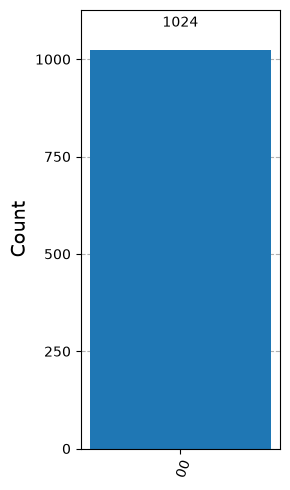

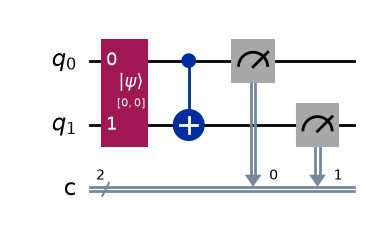

In [4]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer.primitives import SamplerV2
from qiskit.visualization import plot_bloch_multivector, plot_histogram
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, inset_axes

#define circuit with two qubit and a register with two classical bits
q = QuantumRegister(2, 'q')
c = ClassicalRegister(2, 'c')
circuit2 = QuantumCircuit(q,c)

# Define initial_state for both qubits to be alpha=1, beta=0 --> state |00>
initial_state = '00'   
circuit2.initialize(initial_state,[0,1])

# ---- Add extra gates to execute on qubit here----

# Controlled-NOT gate with the qubit q0 as control and qubit q1 as target
circuit2.cx(0,1)

circuit2.measure(q, c)

# define simulator
sampler = SamplerV2()
# execute the circuit with this simulator
job = sampler.run([circuit2]).result()
counts = job[0].data.c.get_counts()

print ("total counts for |00> are:",counts)
# plot histogram
display(plot_histogram(counts,figsize=(3,5)))
# visualize circuit
display(circuit2.draw(output='mpl'))

In the circuit above, both $q_0$ and $q_1$ are initialized in state $|0\rangle$, the initial quantum state of the system is $|00\rangle$. Then, the CNOT gate is applied using $q_0$ as the control qubit and q1 as the target qubit. Since the control qubit is $|0\rangle$, the CNOT has no effect on the target qubit. The state of the system does not change. When measured, we observe state $|00\rangle$ with probability 1.0.

> Q1: What happens if we apply initialize $q_0$ in state $|1\rangle$? (or apply a X gate to $q_0$ before the CNOT?)


## Bell states

> E1: Create a circuit where you apply a Hadamard to the control qubit (q0) before the CNOT

> Q2: Which state do you get? Can you explain the result?

> Q3: Can you write the individual qubit states? What should the values of $\alpha_1$ and $\beta_1$ be?


The quantum state created by the above circuit is one of the so called "Bell states" (https://en.wikipedia.org/wiki/Bell_state). The Bell states are maximally entangled, that means that measuring one already "defines" the value of the other. If we measure $q_0$ at state $|0\rangle$, we know $q_1$ is also in state $|0\rangle$, if we measure $q_0$ in $|1\rangle$ we know $q_1$ is also in state $|1\rangle$. They are somehow linked and this "link" is called entanglement.

More formally (for the curious) an entangle state is a state of the system that can not be described by the individual qubits, only by the whole multi-qubit register (https://en.wikipedia.org/wiki/Quantum_entanglement). 

There are three other Bell states of 2-qubits:

$|\phi^-\rangle = \frac{1}{\sqrt 2}|00\rangle - \frac{1}{\sqrt 2}|11\rangle$ 

$|\psi^+\rangle = \frac{1}{\sqrt 2}|01\rangle + \frac{1}{\sqrt 2}|10\rangle$ 

$|\psi^-\rangle = \frac{1}{\sqrt 2}|01\rangle - \frac{1}{\sqrt 2}|10\rangle$ 

> E2: Try to create these states

> E3: Try measuring one of the two qubits in the Bell state, what do you see?


## GHZ state

The GHZ state is a generalization of the Bell states for a system of 3-qubits.
The state is:
    
$|\psi\rangle = \frac{1}{\sqrt 2}|000\rangle - \frac{1}{\sqrt 2}|111\rangle$ 

> E4: create the GHZ state

In [ ]:
# your code here